# Strategy Backtesting

Backtest combined ML + scalping strategy.

In [2]:
import pandas as pd
import sys
# Add project root to path so `src` is importable from the notebook
sys.path.append('..')

from src.utils.config import DEFAULT_TICKERS, RAW_DATA_DIR
from src.strategy.combined_strategy import generate_combined_strategy
from src.strategy.backtest import SimpleBacktester

In [3]:
# Load data
from pathlib import Path
# Use project tickers
ticker = DEFAULT_TICKERS[1]  # change index to pick another project ticker
# Try multiple relative locations (notebook may run from different working dirs)
candidates = [
    Path('../data/indicators') / f'{ticker}_features.csv',
    Path('../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../../data') / 'indicators' / f'{ticker}_features.csv',
 ]
data = None
for p in candidates:
    if p.exists():
        data = pd.read_csv(p, index_col=0, parse_dates=True)
        print(f'Loaded features from: {p}')
        break
if data is None:
    raise FileNotFoundError(
        f'Could not find {ticker}_features.csv. Checked paths: {', '.join(str(x) for x in candidates)}'
    )

# Generate combined strategy
data = generate_combined_strategy(ticker, data, ml_weight=0.6)

data[['Close', 'ml_signal', 'scalp_signal', 'combined_signal']].tail()

Loaded features from: ..\data\indicators\TCS.NS_features.csv
2025-12-17 17:52:38 - src.strategy.combined_strategy - WARNING - No ML model for TCS.NS → scalping only
2025-12-17 17:52:38 - src.strategy.scalping_logic - INFO - Generated scalping signals → 1127 rows


2025-12-17 17:52:38 - src.strategy.combined_strategy - INFO - Generated combined signals for TCS.NS


c:\Users\Nihar\Documents\GitHub\oop\SnowMore\algo-trading-project\notebooks\..\src\strategy\scalping_logic.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.   0.   0.   0.   0.   1.5 -1.5 -1.5  0.   0.   1.5  0.   0.   1.5
  0.  -1.5 -1.5 -1.5  0.  -1.5  0.  -1.5 -1.5 -1.5 -1.5  0.   0.  -1.5
 -1.5 -1.5 -1.5 -1.5  0.   0.   0.   0.   0.   0.  -1.5  0.   0.   0.
  1.5 -1.5 -1.5 -1.5  0.  -1.5  0.   0.   0.   0.   0.   0.   0.  -1.5
  0.   0.   0.   0.   1.5  0.   0.   1.5  1.5  0.   0.  -1.5  0.   0.
  0.   0.   0.  -1.5  0.   0.   0.   0.   0.   0.  -1.5  1.5  0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.  -1.5  0.   0.  -1.5 -1.5  1.5
 -1.5  0.   0.   0.   0.   0.  -1.5  0.   0.   0.  -1.5  0.   0.   0.
 -1.5  0.   0.   0.   0.   1.5  0.   0.   0.   0.   0.   0.   0.   0.
  0.   1.5  0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[vol_spike

,Close,ml_signal,scalp_signal,combined_signal
Price,,,,
2024-11-21,3935.940918,0,0.0,0
2024-11-22,4101.917480,0,1.0,1
2024-11-28,4102.207031,0,0.0,0
2024-11-29,4127.285156,0,0.0,0
2024-12-02,4132.889648,0,0.0,0


In [4]:
# Run backtest
backtester = SimpleBacktester(initial_capital=100000, commission=0.001)
results = backtester.backtest(data, signal_column='combined_signal')

print('\nBacktest Results:')
for key, value in results.items():
    print(f'{key}: {value}')

2025-12-17 17:52:45 - src.strategy.backtest - INFO - 📊 Backtest Results
2025-12-17 17:52:45 - src.strategy.backtest - INFO - final_equity: 199608.50462536706
2025-12-17 17:52:45 - src.strategy.backtest - INFO - total_return: 0.9960850462536706
2025-12-17 17:52:45 - src.strategy.backtest - INFO - total_trades: 39
2025-12-17 17:52:45 - src.strategy.backtest - INFO - win_rate: 0.5384615384615384
2025-12-17 17:52:45 - src.strategy.backtest - INFO - sharpe_ratio: 1.1440550278544037
2025-12-17 17:52:45 - src.strategy.backtest - INFO - max_drawdown: -0.14370452518230306

Backtest Results:
final_equity: 199608.50462536706
total_return: 0.9960850462536706
total_trades: 39
win_rate: 0.5384615384615384
sharpe_ratio: 1.1440550278544037
max_drawdown: -0.14370452518230306


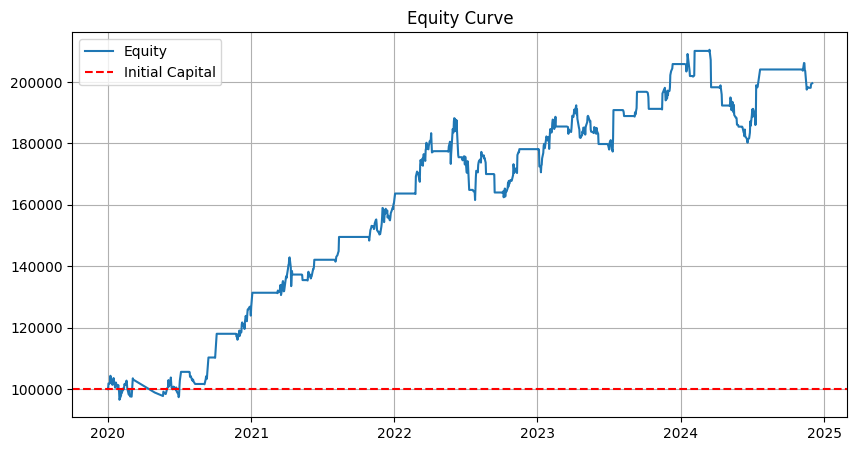

In [5]:
# Plot equity curve
backtester.plot_equity_curve()

In [6]:
# Compare with buy-and-hold
buy_hold_return = (data['Close'].iloc[-1] - data['Close'].iloc[0]) / data['Close'].iloc[0]
print(f'Buy-and-Hold Return: {buy_hold_return:.2%}')
print(f'Strategy Return: {results["total_return"]:.2%}')
print(f'Outperformance: {(results["total_return"] - buy_hold_return):.2%}')

Buy-and-Hold Return: 117.52%
Strategy Return: 99.61%
Outperformance: -17.91%
